Моделирование мотивов в PWM. Энтропия и информационное содержание

In [1]:
pip install numpy matplotlib scipy biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 25.0 MB/s eta 0:00:00


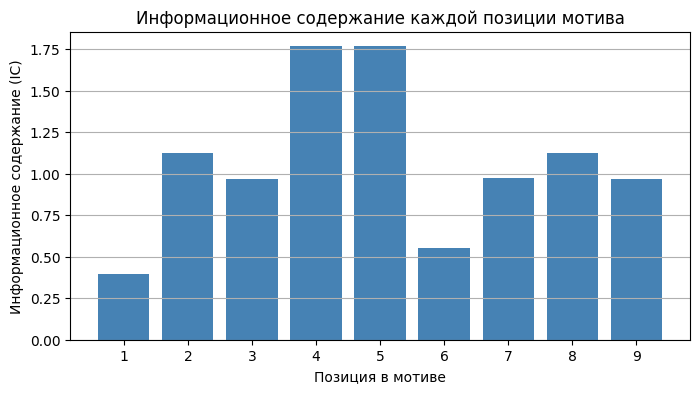

Позиция 1: H=1.603, IC=0.397
Позиция 2: H=0.876, IC=1.124
Позиция 3: H=1.031, IC=0.969
Позиция 4: H=0.234, IC=1.766
Позиция 5: H=0.234, IC=1.766
Позиция 6: H=1.448, IC=0.552
Позиция 7: H=1.025, IC=0.975
Позиция 8: H=0.876, IC=1.124
Позиция 9: H=1.031, IC=0.969
Позиции кор-мотива (IC > 1.0): [2, 4, 5, 8]
Сравните с выравниванием: сайты показывают, что позиции с высоким IC обычно консервативны.


In [18]:
import matplotlib.pyplot as plt

# Используем PPM из Задания 1 (с псевдосчётом 0.1)
ppm = np.array([[0.10576923, 0.77884615, 0.10576923, 0.00961538, 0.00961538, 0.20192308,
                 0.68269231, 0.20192308, 0.10576923],
                [0.58653846, 0.20192308, 0.10576923, 0.00961538, 0.00961538, 0.58653846,
                 0.00961538, 0.00961538, 0.77884615],
                [0.10576923, 0.00961538, 0.77884615, 0.97115385, 0.00961538, 0.00961538,
                 0.29807692, 0.77884615, 0.00961538],
                [0.20192308, 0.00961538, 0.00961538, 0.00961538, 0.97115385, 0.20192308,
                 0.00961538, 0.00961538, 0.10576923]])

# Энтропия Шеннона H(i)
def shannon_entropy(prob_vec):
    entropy = 0.0
    for p in prob_vec:
        if p > 0:
            entropy -= p * np.log2(p)
    return entropy

H = np.array([shannon_entropy(ppm[:, i]) for i in range(ppm.shape[1])])
IC = 2.0 - H
# Столбчатая диаграмма IC
positions = np.arange(1, len(H)+1)  # 1-9
plt.figure(figsize=(8,4))
plt.bar(positions, IC, color='steelblue')
plt.xlabel('Позиция в мотиве')
plt.ylabel('Информационное содержание (IC)')
plt.title('Информационное содержание каждой позиции мотива')
plt.xticks(positions)
plt.grid(axis='y')
plt.savefig("IC_barplot.png", dpi=150)
plt.show()


for i, (ic, h) in enumerate(zip(IC, H)):
    print(f"Позиция {i+1}: H={h:.3f}, IC={ic:.3f}")

# Кор-мотив
core_positions = [i+1 for i, ic in enumerate(IC) if ic > 1.0]
print(f"Позиции кор-мотива (IC > 1.0): {core_positions}")
print("Сравните с выравниванием: сайты показывают, что позиции с высоким IC обычно консервативны.")